### 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, roc_curve, auc,classification_report


### 2. Import dataset


In [2]:
path = (r"C:\Users\user\Desktop\Veredict.id\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
data = pd.read_csv(path)
df= data
df.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
# Info data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

### 3. Data Preprocessing
melakukan pembersihan dan tranformasi data

In [4]:
# Mengecek apakah ada nilai kosong
print("\nJumlah nilai kosong sebelum cleaning:\n", data.isnull().sum())

# Mengecek apakah ada nilai tak terhingga (baik positif maupun negatif)
cek_infinity = np.isinf(df.select_dtypes(include=[np.number])).sum()

print("Daftar kolom yang  memiliki nilai Infinity:")
print(cek_infinity[cek_infinity > 0])


Jumlah nilai kosong sebelum cleaning:
  Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64
Daftar kolom yang  memiliki nilai Infinity:
Flow Bytes/s       30
 Flow Packets/s    34
dtype: int64


In [5]:
#Menghapus data bernilai infinity 

# Ubah semua yang wujudnya tak terhingga jadi status "kosong" (NaN)
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Hitung ada berapa baris yang datanya tidak bersih
jumlah = data.isna().sum().sum()
print(f"Ada {jumlah} data yang tidak bersih.")

#Menghapus data yant bernilai infinity
data.dropna(inplace=True)
print("Data bernilai infinity dibuang! Shape sekarang:", data.shape)

Ada 68 data yang tidak bersih.
Data bernilai infinity dibuang! Shape sekarang: (225711, 79)


In [6]:
# mengecek apakah ada data duplikat
duplicates = data.duplicated()
duplicate_count = duplicates.sum()

# outpurt
print(f"Jumlah baris berisi data duplikat: {duplicate_count}")



Jumlah baris berisi data duplikat: 2629


In [7]:
#Drop Kolom yang tidak diperlukan

data=data.drop(columns=[' Destination Port'])

In [8]:
#Menghapus data duplikat
data = data.drop_duplicates(keep='first')
del duplicates
data.shape

(221264, 78)

In [9]:
# Menghapus spasi berlebih 

# Cek nama kolom asli
print("Sebelum:", data.columns.tolist()[:5])

# membersihkan spasi di depan dan belakang nama kolom
data.columns = data.columns.str.strip()

# Cek hasilnya
print("Sesudah:", data.columns.tolist()[:5])

data.head()

Sebelum: [' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets']
Sesudah: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets']


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### 4. Data Transformation



In [10]:

data['Label'] = data['Label'].map({'BENIGN': 0, 'DDoS': 1})

# Cek apakah sudah berubah
print(data['Label'].value_counts())


Label
1    128014
0     93250
Name: count, dtype: int64


In [11]:
#Memilih fitur X dan Y
# Buang Label dan fitur yang bocor (Data Leakage)
X = data.drop(columns=['Label', 'Fwd Packet Length Max','Fwd Packet Length Mean','Avg Fwd Segment Size'])
y = data['Label']


# Cek ukuran datase
print(f"Bentuk X (Fitur): {X.shape}")
print(f"Bentuk y (Target): {y.shape}")


Bentuk X (Fitur): (221264, 74)
Bentuk y (Target): (221264,)


#### Menghapus Fitur Redundan (Korelasi > 0.95)
Fitur yang memiliki korelasi sangat tinggi satu sama lain akan dihapus untuk mencegah data leakage dan overfitting.

In [12]:
# Menghapus fitur yang redundan berdasarkan korelasi tinggi

# Hitung matriks korelasi absolut
corr_matrix = X.corr().abs()

# Ambil matriks segitiga atas (agar tidak double-counting)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Tahap 1: Hapus fitur dengan korelasi > 0.85
to_drop_1 = [col for col in upper.columns if any(upper[col] > 0.85)]
X = X.drop(columns=to_drop_1)
print(f"Tahap 1 - Fitur dihapus (korelasi > 0.85): {len(to_drop_1)}")

# Tahap 2: Hapus fitur prediktif (leaky features) yang membuat AUC terlalu sempurna
leaky_features = ['Init_Win_bytes_forward', 'Total Length of Fwd Packets', 'Bwd Packets/s', 'Total Fwd Packets', 'Flow Duration', 'Bwd Packet Length Max']
to_drop_2 = [col for col in leaky_features if col in X.columns]
X = X.drop(columns=to_drop_2)
print(f"Tahap 2 - Fitur dihapus manual (leaky features): {len(to_drop_2)}")

print(f"\nTotal fitur dihapus: {len(to_drop_1) + len(to_drop_2)}")
print(f"Jumlah fitur setelah pembersihan: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")
print(f"\nFitur yang tersisa:")
for col in X.columns:
    print(f"  - {col}")

Tahap 1 - Fitur dihapus (korelasi > 0.85): 34
Tahap 2 - Fitur dihapus manual (leaky features): 6

Total fitur dihapus: 40
Jumlah fitur setelah pembersihan: 34
Jumlah sampel: 221264

Fitur yang tersisa:
  - Fwd Packet Length Min
  - Fwd Packet Length Std
  - Bwd Packet Length Min
  - Flow Bytes/s
  - Flow Packets/s
  - Flow IAT Mean
  - Flow IAT Min
  - Fwd IAT Min
  - Bwd IAT Total
  - Bwd IAT Mean
  - Bwd IAT Std
  - Fwd PSH Flags
  - Bwd PSH Flags
  - Fwd URG Flags
  - Bwd URG Flags
  - Min Packet Length
  - FIN Flag Count
  - RST Flag Count
  - PSH Flag Count
  - ACK Flag Count
  - URG Flag Count
  - CWE Flag Count
  - Down/Up Ratio
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd Avg Bulk Rate
  - Init_Win_bytes_backward
  - min_seg_size_forward
  - Active Mean
  - Active Std
  - Idle Std


In [13]:
# Membagi dataset menjadi data latih dan data uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")
print(f"Rasio DDoS di train: {y_train.mean():.4f}")
print(f"Rasio DDoS di test : {y_test.mean():.4f}")

Jumlah data latih: 177011
Jumlah data uji: 44253
Rasio DDoS di train: 0.5786
Rasio DDoS di test : 0.5786


In [14]:
scaler = StandardScaler()

# Fit dan transform pada data latih
X_train_scaled = scaler.fit_transform(X_train)
# mengubah kembali ke df
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Transform pada data uji
X_test_scaled = scaler.transform(X_test)
# Kembalikan jadi DataFrame
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [15]:
model = XGBClassifier(
    n_estimators=40,
    learning_rate=0.05,
    max_depth=1,              
    min_child_weight=15,      # Minimal 15 sampel di leaf node
    gamma=0.8,                  # Penalti tinggi
    subsample=0.5,            # Hanya gunakan 50% data per tree
    colsample_bytree=0.8,     # Hanya gunakan 50% fitur per tree
    reg_alpha=1.0,            # L1 regularization kuat
    reg_lambda=1.0,           # L2 regularization kuat
    random_state=42,
)
# Training Model
model.fit(X_train_scaled, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 5. Evaluasi Model


Hasil evaluasi:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     18650
           1       0.91      1.00      0.95     25603

    accuracy                           0.94     44253
   macro avg       0.95      0.93      0.94     44253
weighted avg       0.95      0.94      0.94     44253



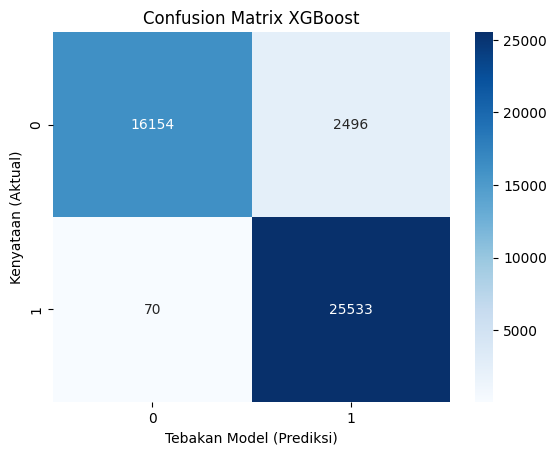

In [16]:
# 1. Suruh model menebak/memprediksi data uji (X_test_scaled)
y_pred = model.predict(X_test_scaled)

print("\nHasil evaluasi:")


print(classification_report(y_test, y_pred))

# Tampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix XGBoost')
plt.xlabel('Tebakan Model (Prediksi)')
plt.ylabel('Kenyataan (Aktual)')
plt.show()

<Figure size 1000x600 with 0 Axes>

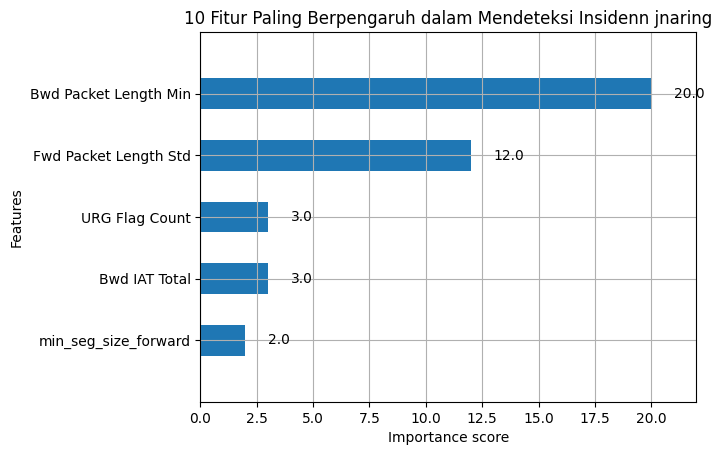

In [17]:
#Menampilkan tingkat kepentingan fitur
# Menampilkan 10 Fitur Paling Penting

plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10, importance_type='weight', height=0.5)
plt.title('10 Fitur Paling Berpengaruh dalam Mendeteksi Insidenn jnaring')
plt.show()



In [18]:
# 1. Setup K-Fold (
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)



scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

# 4. Jalankan Cross Validation
results = cross_validate(model, X, y, cv=kfold, scoring=scoring_metrics)

# 5. Tampilkan Hasil Rata-rata
print(f"=== Hasil K-Fold Cross Validation ({kfold.get_n_splits()} Folds) ===")
print(f"Rata-rata Accuracy : {np.mean(results['test_accuracy'])*100:.2f}%")
print(f"Rata-rata Precision: {np.mean(results['test_precision'])*100:.2f}%")
print(f"Rata-rata Recall   : {np.mean(results['test_recall'])*100:.2f}%")
print(f"Rata-rata F1-Score : {np.mean(results['test_f1'])*100:.2f}%")

# Cek standar deviasi 
print(f"\nStabilitas (Std Dev Accuracy): {np.std(results['test_accuracy']):.4f}")

=== Hasil K-Fold Cross Validation (10 Folds) ===
Rata-rata Accuracy : 94.06%
Rata-rata Precision: 95.25%
Rata-rata Recall   : 92.99%
Rata-rata F1-Score : 93.77%

Stabilitas (Std Dev Accuracy): 0.0015


Nilai AUC Kelas 0 = 0.9745
Nilai AUC Kelas 1 = 0.9745


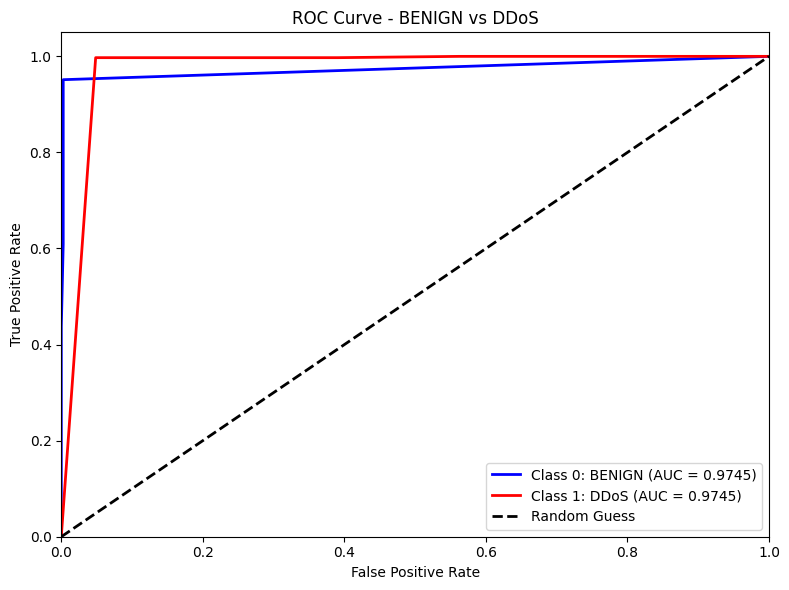

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Dapatkan probabilitas prediksi untuk kedua kelas
y_score = model.predict_proba(X_test_scaled)

# 2. Hitung ROC Curve buat Kelas 0 (BENIGN)
fpr_0, tpr_0, _ = roc_curve(y_test == 0, y_score[:, 0])
roc_auc_0 = auc(fpr_0, tpr_0)

# 3. Hitung ROC Curve buat Kelas 1 (DDoS)
fpr_1, tpr_1, _ = roc_curve(y_test == 1, y_score[:, 1])
roc_auc_1 = auc(fpr_1, tpr_1)

print(f"Nilai AUC Kelas 0 = {roc_auc_0:0.4f}")
print(f"Nilai AUC Kelas 1 = {roc_auc_1:0.4f}")

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_0, tpr_0, color='blue', lw=2, label=f'Class 0: BENIGN (AUC = {roc_auc_0:0.4f})')
plt.plot(fpr_1, tpr_1, color='red', lw=2, label=f'Class 1: DDoS (AUC = {roc_auc_1:0.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BENIGN vs DDoS')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
import joblib

# Simpan Scaler 
joblib.dump(scaler, 'scaler_ddos.joblib')

# Simpan Daftar Nama Kolom 
joblib.dump(X.columns.tolist(), 'feature_columns.joblib')

print("Aset berhasil disimpan! Sekarang silakan refresh/jalankan kembali aplikasi Streamlit.")



Aset berhasil disimpan! Sekarang silakan refresh/jalankan kembali aplikasi Streamlit.


In [22]:
# Simpan dataset hasil pembersihan (Cleaning & Transformation) ke CSV
data.to_csv('cleaned_dataset_veredict.csv', index=False)

print("Dataset bersih berhasil diekspor dengan nama: cleaned_dataset_veredict.csv")


Dataset bersih berhasil diekspor dengan nama: cleaned_dataset_veredict.csv


In [ ]:
#Menyimpan metrik ke streamlit
metrics = {
    'kfold_acc': 94.06,
    'kfold_prec': 95.25,
    'kfold_rec': 92.99,
    'kfold_f1': 93.77,
    'roc_auc': 0.9745
}
joblib.dump(metrics, 'model_metrics.joblib')
print("Metrik berhasil diekspor!")

Metrik berhasil diekspor!
